# Pepper Quality Grading: Detection + Cropping + Classification (Training and Testing)

# Part A: Object Detection Model Training and Comparison

## 1. Environment Setup and Drive Mount

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
!pip install ultralytics==8.3.0 torch torchvision albumentations opencv-python pycocotools effdet timm

from ultralytics import YOLO
import torch
import time
import json
from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/pepper_model_results"

## 2. YOLO Dataset Upload and Extraction

In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/pepper_dataset"

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving yolo_dataset.zip to yolo_dataset.zip


In [ ]:
!mkdir -p $DATASET_ROOT
!unzip yolo_dataset.zip -d $DATASET_ROOT

Archive:  yolo_dataset.zip
   creating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/data.yaml  
   creating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/
   creating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/full_01.jpg  
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/full_02.jpg  
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/full_03.jpg  
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/full_04.jpg  
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/full_05.jpg  
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/full_06.jpg  
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_dataset/images/all/full_07.jpg  
  inflating: /content/drive/MyDrive/pepper_dataset/yolo_datas

In [ ]:
from pathlib import Path

assert Path(f"{DATASET_ROOT}/yolo_dataset/data.yaml").exists(), "Dataset not found!"
print("✅ Dataset loaded from Google Drive")

✅ Dataset loaded from Google Drive


## 3. Train and Validation Split Preparation (YOLO Format)

In [ ]:
import random
import shutil
from pathlib import Path

random.seed(42)

BASE = Path("/content/drive/MyDrive/pepper_dataset/yolo_dataset")
IMG_ALL = BASE / "images/all"
LBL_ALL = BASE / "labels/all"

IMG_TRAIN = BASE / "images/train"
IMG_VAL = BASE / "images/val"
LBL_TRAIN = BASE / "labels/train"
LBL_VAL = BASE / "labels/val"

for p in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    p.mkdir(parents=True, exist_ok=True)

def clear_dir(path):
    for f in path.glob("*"):
        f.unlink()

for p in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    clear_dir(p)

images = list(IMG_ALL.glob("*.jpg"))
assert len(images) > 0, "No images found in images/all"

random.shuffle(images)

split_ratio = 0.8
split_idx = int(len(images) * split_ratio)

train_imgs = images[:split_idx]
val_imgs = images[split_idx:]

def copy_pairs(img_list, img_dst, lbl_dst):
    for img in img_list:
        lbl = LBL_ALL / f"{img.stem}.txt"
        assert lbl.exists(), f"Missing label for {img.name}"
        shutil.copy(img, img_dst / img.name)
        shutil.copy(lbl, lbl_dst / lbl.name)

copy_pairs(train_imgs, IMG_TRAIN, LBL_TRAIN)
copy_pairs(val_imgs, IMG_VAL, LBL_VAL)

print(f"Train images: {len(train_imgs)}")
print(f"Val images: {len(val_imgs)}")

Train images: 24
Val images: 6


## 4. Model Selection

Multiple object detection models are evaluated in this study to justify the final model selection.  
The selected models represent both single-stage and two-stage detectors, allowing a fair comparison in terms of accuracy, speed, and model size.

The following models are considered:
- YOLOv8 (Nano and Small variants)
- YOLOv10 (Small variant)
- Faster R-CNN
- EfficientDet-D0


## 5. Training Configuration

In [ ]:
EPOCHS = 200
BATCH_SIZE = 4
IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else "cpu"
AMP = True if DEVICE != "cpu" else False

# Store results for comparison
results_dict = {}

In [ ]:
WEIGHTS_ROOT = "/content/drive/MyDrive/pepper_model_results/weights"
Path(WEIGHTS_ROOT).mkdir(parents=True, exist_ok=True)

In [ ]:
from pathlib import Path
from collections import Counter

LBL_TRAIN = Path("/content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/train")

counts = Counter()
for txt in LBL_TRAIN.glob("*.txt"):
    for line in txt.read_text().strip().splitlines():
        if not line.strip():
            continue
        cls = int(line.split()[0])
        counts[cls] += 1

print("Box counts per class id:", counts)

Box counts per class id: Counter({2: 3640, 0: 939, 1: 253})


In [ ]:
import shutil
from pathlib import Path

IMG_TRAIN = Path("/content/drive/MyDrive/pepper_dataset/yolo_dataset/images/train")
LBL_TRAIN = Path("/content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/train")

# class ids based on your model.names:
# 0 adulterant_seed, 1 extraneous_matter, 2 pepper_berry
MINORITY = {0, 1}

def has_minority(lbl_path: Path):
    if not lbl_path.exists():
        return False
    for line in lbl_path.read_text().splitlines():
        if not line.strip():
            continue
        cls = int(line.split()[0])
        if cls in MINORITY:
            return True
    return False

minority_imgs = []
for img_path in IMG_TRAIN.glob("*.jpg"):
    lbl_path = LBL_TRAIN / f"{img_path.stem}.txt"
    if has_minority(lbl_path):
        minority_imgs.append(img_path)

print("Images containing minority classes:", len(minority_imgs))

# duplicate each minority image N times
N_DUP = 5  # try 3, 5, 8 depending on imbalance

for img_path in minority_imgs:
    lbl_path = LBL_TRAIN / f"{img_path.stem}.txt"
    for k in range(N_DUP):
        new_stem = f"{img_path.stem}_dup{k}"
        shutil.copy(img_path, IMG_TRAIN / f"{new_stem}.jpg")
        shutil.copy(lbl_path, LBL_TRAIN / f"{new_stem}.txt")

print("✅ Oversampling done. Re-train YOLO now.")

Images containing minority classes: 18
✅ Oversampling done. Re-train YOLO now.


## 6. Training YOLO Models

### 6.1 Training YOLOv8n

In [ ]:
print("\n" + "="*50)
print("TRAINING YOLOv8n")
print("="*50)

model_v8n = YOLO("yolov8n.pt")
start_time = time.time()

results_v8n = model_v8n.train(
    data=f"{DATASET_ROOT}/yolo_dataset/data.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    lr0=0.001,
    freeze=10,
    patience=15,  # Early stopping
    save=True,
    plots=True,
    amp=AMP,  # Mixed precision training
    augment=True,  # IMPORTANT: Heavy augmentation for small dataset
    hsv_h=0.015,  # Color augmentation
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,  # Rotation
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,  # Mosaic augmentation
    mixup=0.0 if DEVICE == "cpu" else 0.1,
    save_dir=f"{PROJECT_ROOT}/yolov8n",
)

train_time_v8n = time.time() - start_time
val_results_v8n = model_v8n.val(device=DEVICE)
best_path = Path(model_v8n.trainer.best)

results_dict['YOLOv8n'] = {
    'train_time': train_time_v8n,
    'mAP50': val_results_v8n.box.map50,
    'mAP50-95': val_results_v8n.box.map,
    'params': sum(p.numel() for p in model_v8n.model.parameters()),
    'best_path': str(best_path),
    'model_size_mb': best_path.stat().st_size / 1e6 if best_path.exists() else None,

}


TRAINING YOLOv8n


100%|██████████| 6.25M/6.25M [00:00<00:00, 187MB/s]


New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/pepper_dataset/yolo_dataset/data.yaml, epochs=200, time=None, patience=15, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=10, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=Non

100%|██████████| 755k/755k [00:00<00:00, 43.5MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

                   all          6       1477      0.522      0.419      0.438      0.265
       adulterant_seed          1         10     0.0904        0.1     0.0291     0.0181
     extraneous_matter          3         24      0.622       0.25      0.367      0.182
          pepper_berry          6       1443      0.852      0.908      0.919      0.595
Speed: 0.4ms preprocess, 1196.1ms inference, 0.0ms loss, 7.7ms postprocess per image
Results saved to runs/detect/train


lr/pg0,▁▁▂▂▃▅▅▆▆██████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▄
lr/pg1,▁▃▃▄▅█████████▇▇▇▇▇▆▆▆▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▄
lr/pg2,▁▃▃▅▅████▇▇▇▇▇▆▆▆▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▂▂
metrics/mAP50(B),▁▁▁▁▁▁▁▂▃▅▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████
metrics/mAP50-95(B),▁▁▁▁▁▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████▇
metrics/precision(B),▁▁▁▁▃▃▄▄▄▄██████████▅▅▆▆▆▅▆▅▅▅▆▆▆▇▇▇▆▇█▆
metrics/recall(B),▁▁▁▁▁▁▁▁▂▄▆▇▇▆▆▇▇▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 2,684,953 parameters, 0 gradients, 6.8 GFLOPs


val: Scanning /content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6/6 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:05<00:00,  2.94s/it]


                   all          6       1477      0.524       0.42      0.439      0.267
       adulterant_seed          1         10      0.085        0.1     0.0286     0.0178
     extraneous_matter          3         24      0.622       0.25      0.361      0.183
          pepper_berry          6       1443      0.867      0.911      0.928        0.6
Speed: 0.3ms preprocess, 291.7ms inference, 0.0ms loss, 12.5ms postprocess per image
Results saved to runs/detect/train2


In [ ]:
from pathlib import Path
import shutil

best_path = Path(model_v8n.trainer.best)

dst = Path(WEIGHTS_ROOT) / "yolov8n_best.pt"
dst.parent.mkdir(parents=True, exist_ok=True)

shutil.copy(best_path, dst)

print(f"✅ YOLOv8n best model saved to {dst}")


✅ YOLOv8n best model saved to /content/drive/MyDrive/pepper_model_results/weights/yolov8n_best.pt


### 6.2 Training YOLOv8s

In [ ]:
print("\n" + "="*50)
print("TRAINING YOLOv8s")
print("="*50)

model_v8s = YOLO("yolov8s.pt")
start_time = time.time()

results_v8s = model_v8s.train(
    data=f"{DATASET_ROOT}/yolo_dataset/data.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,

    lr0=0.001,
    freeze=0,
    patience=20,
    amp=AMP,

    # augmentations (valid for detect)
    augment=True,
    mosaic=1.0,
    mixup=0.1,
    close_mosaic=10,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,

    save=True,
    plots=True,
    save_dir=f"{PROJECT_ROOT}/yolov8s_balanced_fixed"
)

train_time_v8s = time.time() - start_time
val_results_v8s = model_v8s.val(device=DEVICE)
best_path = Path(model_v8s.trainer.best)

results_dict['YOLOv8s'] = {
    'train_time': train_time_v8s,
    'mAP50': val_results_v8s.box.map50,
    'mAP50-95': val_results_v8s.box.map,
    'params': sum(p.numel() for p in model_v8s.model.parameters()),
    'best_path': str(best_path),
    'model_size_mb': best_path.stat().st_size / 1e6 if best_path.exists() else None,
}

print("Best model:", best_path)
print("mAP50:", val_results_v8s.box.map50)
print("mAP50-95:", val_results_v8s.box.map)


TRAINING YOLOv8s
New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/pepper_dataset/yolo_dataset/data.yaml, epochs=200, time=None, patience=20, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=0, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_mask

Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...
AMP: checks passed ✅


train: Scanning /content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/train... 114 images, 0 backgrounds, 0 corrupt: 100%|██████████| 114/114 [00:01<00:00, 64.89it/s]


train: New cache created: /content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6/6 [00:00<?, ?it/s]


...

                   all          6       1477      0.836      0.775      0.838      0.641
       adulterant_seed          1         10      0.868       0.66      0.813      0.621
     extraneous_matter          3         24      0.668      0.708      0.727      0.556
          pepper_berry          6       1443      0.971      0.956      0.974      0.745
Speed: 0.3ms preprocess, 25.6ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to runs/detect/train5


lr/pg0,▁███████▇▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▄
lr/pg1,▁████▇▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄
lr/pg2,▁█████▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▄▄
metrics/mAP50(B),▁▃▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▆▇█▆▇▇▆▇██████▇▇███▇
metrics/mAP50-95(B),▁▂▃▄▄▃▅▅▆▅▆▅▆▆▆▆▆▆▅▆▆▆▆▆▇▇█▇▇█▇██▇▆▇▇▇▇█
metrics/precision(B),▁▂█▅▄▆▇▅▅▇▅▅▆▆▆▆▇▇▅█▅▆▆▆▇▇▇▇▇▇█▇█▇█▇▆▇▇▇
metrics/recall(B),▁▂▄▅▇▆▆▅▆▆▆▇▇▇▆▆█▆▆▆▇▆▇▇▅▇▆█▇█▇▇█▇▇▆▅▇▇█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 186 layers, 9,828,825 parameters, 0 gradients, 23.3 GFLOPs


val: Scanning /content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6/6 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:03<00:00,  1.97s/it]


                   all          6       1477       0.85      0.789      0.853      0.648
       adulterant_seed          1         10      0.868      0.661      0.813      0.621
     extraneous_matter          3         24      0.707       0.75      0.773       0.57
          pepper_berry          6       1443      0.976      0.956      0.974      0.753
Speed: 0.3ms preprocess, 71.1ms inference, 0.0ms loss, 8.6ms postprocess per image
Results saved to runs/detect/train52
Best model: runs/detect/train5/weights/best.pt
mAP50: 0.853444876481516
mAP50-95: 0.6480398136189999


In [ ]:
from pathlib import Path
import shutil

best_path = Path(model_v8s.trainer.best)

dst = Path(WEIGHTS_ROOT) / "yolov8s_best.pt"
dst.parent.mkdir(parents=True, exist_ok=True)

shutil.copy(best_path, dst)

print(f"✅ YOLOv8s best model saved to {dst}")


✅ YOLOv8s best model saved to /content/drive/MyDrive/pepper_model_results/weights/yolov8s_best.pt


### 6.3 Training YOLOv10s

In [ ]:
print("\n" + "="*50)
print("TRAINING YOLOv10s")
print("="*50)

model_v10s = YOLO("yolov10s.pt")
start_time = time.time()

results_v10s = model_v10s.train(
    data=f"{DATASET_ROOT}/yolo_dataset/data.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    lr0=0.001,
    freeze=15,
    patience=15,
    save=True,
    plots=True,
    amp=AMP,
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0 if DEVICE == "cpu" else 0.1,
    save_dir=f"{PROJECT_ROOT}/yolov10s"
)

train_time_v10s = time.time() - start_time
val_results_v10s = model_v10s.val(device=DEVICE)
best_path = Path(model_v10s.trainer.best)

results_dict['YOLOv10s'] = {
    'train_time': train_time_v10s,
    'mAP50': val_results_v10s.box.map50,
    'mAP50-95': val_results_v10s.box.map,
    'params': sum(p.numel() for p in model_v10s.model.parameters()),
    'best_path': str(best_path),
    'model_size_mb': best_path.stat().st_size / 1e6 if best_path.exists() else None,
}


TRAINING YOLOv10s


100%|██████████| 15.9M/15.9M [00:00<00:00, 36.9MB/s]


New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov10s.pt, data=/content/drive/MyDrive/pepper_dataset/yolo_dataset/data.yaml, epochs=200, time=None, patience=15, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=15, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=N

Freezing layer 'model.0.conv.weight'
Freezing layer 'model.0.bn.weight'
Freezing layer 'model.0.bn.bias'
Freezing layer 'model.1.conv.weight'
Freezing layer 'model.1.bn.weight'
Freezing layer 'model.1.bn.bias'
Freezing layer 'model.2.cv1.conv.weight'
Freezing layer 'model.2.cv1.bn.weight'
Freezing layer 'model.2.cv1.bn.bias'
Freezing layer 'model.2.cv2.conv.weight'
Freezing layer 'model.2.cv2.bn.weight'
Freezing layer 'model.2.cv2.bn.bias'
Freezing layer 'model.2.m.0.cv1.conv.weight'
Freezing layer 'model.2.m.0.cv1.bn.weight'
Freezing layer 'model.2.m.0.cv1.bn.bias'
Freezing layer 'model.2.m.0.cv2.conv.weight'
Freezing layer 'model.2.m.0.cv2.bn.weight'
Freezing layer 'model.2.m.0.cv2.bn.bias'
Freezing layer 'model.3.conv.weight'
Freezing layer 'model.3.bn.weight'
Freezing layer 'model.3.bn.bias'
Freezing layer 'model.4.cv1.conv.weight'
Freezing layer 'model.4.cv1.bn.weight'
Freezing layer 'model.4.cv1.bn.bias'
Freezing layer 'model.4.cv2.conv.weight'
Freezing layer 'model.4.cv2.bn.weig

train: Scanning /content/drive/MyDrive/pepper_dataset/yolo_dataset/labels/train.cache... 24 images, 0 backgrounds, 0 corrupt: 100%|██████████| 24/24 [00:00<?, ?it/s]

...

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  50%|█████     | 1/2 [00:01<00:01,  1.18s/it]

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


                   all          6       1477      0.919      0.293      0.444      0.241
       adulterant_seed          1         10          1          0          0          0
     extraneous_matter          3         24          1     0.0417      0.521      0.208
          pepper_berry          6       1443      0.756      0.839      0.812      0.514
Speed: 1.1ms preprocess, 27.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/train42


In [ ]:
from pathlib import Path
import shutil

best_path = Path(model_v10s.trainer.best)

dst = Path(WEIGHTS_ROOT) / "yolov10s_best.pt"
dst.parent.mkdir(parents=True, exist_ok=True)

shutil.copy(best_path, dst)

print(f"✅ YOLOv10s best model saved to {dst}")


✅ YOLOv10s best model saved to /content/drive/MyDrive/pepper_model_results/weights/yolov10s_best.pt


## 7. Training FASTER R-CNN Model

In [ ]:
!pip install torch torchvision albumentations opencv-python

In [ ]:
print("\n" + "="*50)
print("TRAINING Faster R-CNN")
print("="*50)

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np

class PepperDataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    cls, x, y, bw, bh = map(float, line.split())
                    x1 = max(0, (x - bw / 2) * w)
                    y1 = max(0, (y - bh / 2) * h)
                    x2 = min(w, (x + bw / 2) * w)
                    y2 = min(h, (y + bh / 2) * h)

                    if x2 > x1 and y2 > y1:  # Valid box
                        boxes.append([x1, y1, x2, y2])
                        labels.append(int(cls) + 1)

        if len(boxes) == 0:  # Handle empty annotations
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0

        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

# Create datasets
train_dataset = PepperDataset(
    f"{DATASET_ROOT}/yolo_dataset/images/train",
    f"{DATASET_ROOT}/yolo_dataset/labels/train"
)

# Use train as val for now due to small dataset
val_dataset = PepperDataset(
    f"{DATASET_ROOT}/yolo_dataset/images/train",
    f"{DATASET_ROOT}/yolo_dataset/labels/train"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,  # Reduced from 2
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,  # Changed from 2 - critical fix!
    pin_memory=False  # Disable to save memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,  # Reduced from 2
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,  # Changed from 2
    pin_memory=False
)

# Initialize model
model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Freeze backbone
for param in model_frcnn.backbone.parameters():
    param.requires_grad = False

num_classes = 4  # 3 classes + background
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_frcnn.to(device)

params = [p for p in model_frcnn.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)

# Train
start_time = time.time()
num_epochs = 40  # Reduced for Faster R-CNN

for epoch in range(num_epochs):
    model_frcnn.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Skip batches with no valid boxes
        if all(len(t['boxes']) == 0 for t in targets):
            continue

        loss_dict = model_frcnn(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

train_time_frcnn = time.time() - start_time

results_dict['Faster R-CNN'] = {
    'train_time': train_time_frcnn,
    'mAP50': 'N/A - Use COCO eval for proper metrics',
    'mAP50-95': 'N/A',
    'params': sum(p.numel() for p in model_frcnn.parameters())
}


TRAINING Faster R-CNN
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 89.8MB/s]


Epoch 1/40, Loss: 36.6778
Epoch 2/40, Loss: 15.9357
Epoch 3/40, Loss: 13.1070
Epoch 4/40, Loss: 11.8078
Epoch 5/40, Loss: 11.7399
Epoch 6/40, Loss: 11.5985
Epoch 7/40, Loss: 11.2345
Epoch 8/40, Loss: 10.0456
Epoch 9/40, Loss: 9.4760
Epoch 10/40, Loss: 9.9478
Epoch 11/40, Loss: 9.7769
Epoch 12/40, Loss: 9.6708
Epoch 13/40, Loss: 9.6045
Epoch 14/40, Loss: 8.7982
Epoch 15/40, Loss: 9.1770
Epoch 16/40, Loss: 8.8260
Epoch 17/40, Loss: 8.5907
Epoch 18/40, Loss: 8.3998
Epoch 19/40, Loss: 8.6962
Epoch 20/40, Loss: 8.2536
Epoch 21/40, Loss: 7.9458
Epoch 22/40, Loss: 8.0110
Epoch 23/40, Loss: 8.3715
Epoch 24/40, Loss: 8.3718
Epoch 25/40, Loss: 7.9583
Epoch 26/40, Loss: 7.7512
Epoch 27/40, Loss: 7.6677
Epoch 28/40, Loss: 8.1257
Epoch 29/40, Loss: 7.8282
Epoch 30/40, Loss: 7.2505
Epoch 31/40, Loss: 8.1287
Epoch 32/40, Loss: 7.4494
Epoch 33/40, Loss: 7.4061
Epoch 34/40, Loss: 7.1085
Epoch 35/40, Loss: 7.0428
Epoch 36/40, Loss: 7.6273
Epoch 37/40, Loss: 7.2479
Epoch 38/40, Loss: 7.3958
Epoch 39/40, 

In [ ]:
from pathlib import Path
import torch

WEIGHTS_ROOT = f"{PROJECT_ROOT}/weights"
Path(WEIGHTS_ROOT).mkdir(parents=True, exist_ok=True)

faster_rcnn_path = Path(WEIGHTS_ROOT) / "faster_rcnn_best.pth"

torch.save(model_frcnn.state_dict(), faster_rcnn_path)

print(f"✅ Faster R-CNN model saved to {faster_rcnn_path}")

✅ Faster R-CNN model saved to /content/drive/MyDrive/pepper_model_results/weights/faster_rcnn_best.pth


In [ ]:
results_dict['Faster R-CNN']['model_size_mb'] = faster_rcnn_path.stat().st_size / 1e6

## 8. Training EfficientDet-D0 Model

In [ ]:
efficientdet_best_path = Path(WEIGHTS_ROOT) / "efficientdet_d0_best.pth"

In [ ]:
print("\n" + "="*50)
print("TRAINING EfficientDet-D0")
print("="*50)

from effdet import get_efficientdet_config, EfficientDet, DetBenchTrain
from effdet.efficientdet import HeadNet
import albumentations as A
from albumentations.pytorch import ToTensorV2

class PepperDatasetEffDet(Dataset):
    def __init__(self, img_dir, label_dir, img_size=512, mode='train'):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.images = [f for f in os.listdir(img_dir) if f.endswith(".jpg")]

        if mode == 'train':
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))
        else:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f.readlines():
                    cls, xc, yc, bw, bh = map(float, line.split())
                    x1 = max(0, (xc - bw / 2) * w)
                    y1 = max(0, (yc - bh / 2) * h)
                    x2 = min(w, (xc + bw / 2) * w)
                    y2 = min(h, (yc + bh / 2) * h)

                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(int(cls))

        if len(boxes) > 0:
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['labels']

            if len(boxes) > 0:
                boxes = torch.tensor(boxes, dtype=torch.float32)
                labels = torch.tensor(labels, dtype=torch.int64)
            else:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros((0,), dtype=torch.int64)
        else:
            transformed = self.transform(image=image, bboxes=[], labels=[])
            image = transformed['image']
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            'bbox': boxes,
            'cls': labels,
            'img_size': torch.tensor([self.img_size, self.img_size]),
            'img_scale': torch.tensor([1.0])
        }

        return image, target

def collate_fn_effdet(batch):
    images = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]

    max_num_annots = max(len(t['bbox']) for t in targets)
    if max_num_annots == 0:
        max_num_annots = 1

    batch_size = len(images)
    bbox_batch = torch.zeros((batch_size, max_num_annots, 4))
    cls_batch = torch.zeros((batch_size, max_num_annots), dtype=torch.int64)

    for idx, target in enumerate(targets):
        num_objs = len(target['bbox'])
        if num_objs > 0:
            bbox_batch[idx, :num_objs, :] = target['bbox']
            cls_batch[idx, :num_objs] = target['cls']

    return images, {'bbox': bbox_batch, 'cls': cls_batch}

# Setup
train_dataset_eff = PepperDatasetEffDet(
    img_dir=f"{DATASET_ROOT}/yolo_dataset/images/train",
    label_dir=f"{DATASET_ROOT}/yolo_dataset/labels/train",
    mode='train'
)

val_dataset_eff = PepperDatasetEffDet(
    img_dir=f"{DATASET_ROOT}/yolo_dataset/images/train",
    label_dir=f"{DATASET_ROOT}/yolo_dataset/labels/train",
    mode='val'
)

train_loader_eff = DataLoader(
    train_dataset_eff,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn_effdet,
    pin_memory=True
)

val_loader_eff = DataLoader(
    val_dataset_eff,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn_effdet,
    pin_memory=True
)

# Model setup
config = get_efficientdet_config("tf_efficientdet_d0")
config.num_classes = 3
config.image_size = (512, 512)

net = EfficientDet(config, pretrained_backbone=True)
net.class_net = HeadNet(config, num_outputs=config.num_classes)

model_eff = DetBenchTrain(net, config)
model_eff.to(device)

optimizer_eff = torch.optim.AdamW(model_eff.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=50, eta_min=1e-6)

# Train
start_time = time.time()
num_epochs_eff = 40  # Reduced
best_loss = float('inf')

for epoch in range(num_epochs_eff):
    model_eff.train()
    train_loss = 0.0
    train_batches = 0

    for batch_idx, (images, targets) in enumerate(train_loader_eff):
        try:
            images = images.to(device)
            targets_device = {
                'bbox': targets['bbox'].to(device),
                'cls': targets['cls'].to(device)
            }

            output = model_eff(images, targets_device)
            loss = output['loss']

            optimizer_eff.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_eff.parameters(), max_norm=10.0)
            optimizer_eff.step()

            train_loss += loss.item()
            train_batches += 1

        except Exception as e:
            print(f"Error in batch {batch_idx}: {e}")
            continue

    avg_train_loss = train_loss / max(train_batches, 1)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs_eff}], Train Loss: {avg_train_loss:.4f}")

    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        torch.save({
          'epoch': epoch,
          'model_state_dict': model_eff.state_dict(),
          'optimizer_state_dict': optimizer_eff.state_dict(),
          'loss': best_loss,
        }, efficientdet_best_path)

train_time_eff = time.time() - start_time

results_dict['EfficientDet-D0'] = {
    'train_time': train_time_eff,
    'mAP50': 'N/A - Requires proper COCO eval',
    'mAP50-95': 'N/A',
    'params': sum(p.numel() for p in model_eff.parameters()),
    'model_size_mb': efficientdet_best_path.stat().st_size / 1e6
}


TRAINING EfficientDet-D0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch [1/40], Train Loss: 116.5946
Epoch [2/40], Train Loss: 116.5510
Epoch [3/40], Train Loss: 114.9349
Epoch [4/40], Train Loss: 114.6529
Epoch [5/40], Train Loss: 113.7233
Epoch [6/40], Train Loss: 112.5229
Epoch [7/40], Train Loss: 110.7005
Epoch [8/40], Train Loss: 111.8416
Epoch [9/40], Train Loss: 110.8257
Epoch [10/40], Train Loss: 109.7544
Epoch [11/40], Train Loss: 107.4780
Epoch [12/40], Train Loss: 107.5176
Epoch [13/40], Train Loss: 107.2048
Epoch [14/40], Train Loss: 107.2367
Epoch [15/40], Train Loss: 105.1405
Epoch [16/40], Train Loss: 104.1713
Epoch [17/40], Train Loss: 102.9729
Epoch [18/40], Train Loss: 104.5821
Epoch [19/40], Train Loss: 100.7294
Epoch [20/40], Train Loss: 100.3800
Epoch [21/40], Train Loss: 100.4028
Epoch [22/40], Train Loss: 100.6412
Epoch [23/40], Train Loss: 98.6895
Epoch [24/40], Train Loss: 97.8629
Epoch [25/40], Train Loss: 98.7268
Epoch [26/40], Train Loss: 98.1505
Epoch [27/40], Train Loss: 97.1305
Epoch [28/40], Train Loss: 96.8976
Epoch [

## 9. Comparative Analysis

In [ ]:
print("\n" + "="*70)
print("FINAL COMPARISON RESULTS")
print("="*70)

import pandas as pd
df = pd.DataFrame(results_dict).T
print(df)

# Save to JSON
with open(f"{PROJECT_ROOT}/model_comparison_results.json", 'w') as f:
    json.dump(results_dict, f, indent=2)

print("\n✅ Training complete! Results saved to model_comparison_results.json")
print("\n📊 Key Takeaways")
print("1. YOLOv8n: Fastest and smallest model, suitable for mobile and edge deployment with acceptable detection performance.")
print("2. YOLOv8s: Achieved the highest detection accuracy among evaluated YOLO models while remaining lightweight, making it the most suitable choice for the proposed system.")
print("3. YOLOv10s: Modern architecture but showed reduced performance on the limited dataset, indicating sensitivity to data size.")
print("4. Faster R-CNN: Two-stage detector with high computational cost and model size, making it unsuitable for real-time or mobile deployment.")
print("5. EfficientDet-D0: Architecturally efficient model but required a complex training pipeline and showed limited practicality on small datasets.")


FINAL COMPARISON RESULTS
               train_time                                   mAP50  mAP50-95  \
YOLOv8n        374.968054                                0.439101   0.26704   
YOLOv8s       2085.438204                                0.853445   0.64804   
YOLOv10s       160.253381                                0.444225  0.240889   
Faster R-CNN   495.359763  N/A - Use COCO eval for proper metrics       N/A   

                params                           best_path model_size_mb  
YOLOv8n        2684953   runs/detect/train/weights/best.pt      5.630774  
YOLOv8s        9828825  runs/detect/train5/weights/best.pt     19.949174  
YOLOv10s       8037282  runs/detect/train4/weights/best.pt     16.523458  
Faster R-CNN  41309411                                 NaN    165.771398  

✅ Training complete! Results saved to model_comparison_results.json

📊 Key Takeaways
1. YOLOv8n: Fastest and smallest model, suitable for mobile and edge deployment with acceptable detection performance

# Part B: Post-Training Inference

## 1. Inference Setup (YOLO)

In [ ]:
!pip install ultralytics==8.3.0

In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
from collections import Counter
import cv2
import matplotlib.pyplot as plt

## 2. Upload Test Image

In [ ]:
uploaded = files.upload()

Saving half_24.jpg to half_24.jpg


## 3. Load Best YOLO Model (YOLOv8s)

In [ ]:
model = YOLO("/content/drive/MyDrive/pepper_model_results/weights/yolov8s_best.pt")

In [ ]:
print(model.names)

{0: 'adulterant_seed', 1: 'extraneous_matter', 2: 'pepper_berry'}


## 4. Run Detection on Uploaded Image

In [ ]:
image_name = list(uploaded.keys())[0]

results = model(
    image_name,
    conf=0.25,
    iou=0.5
)


image 1/1 /content/half_24.jpg: 640x480 4 extraneous_matters, 296 pepper_berrys, 67.4ms
Speed: 5.0ms preprocess, 67.4ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 480)


## 5. Save and Display Detection Output

In [ ]:
results[0].save(filename="detected_output.jpg")
display(Image(filename="detected_output.jpg"))

## 6. Count Detected Objects by Class

In [ ]:
result = results[0]

class_ids = result.boxes.cls.cpu().numpy()
class_names = model.names

labels = [class_names[int(c)] for c in class_ids]
counts = Counter(labels)

print("Detection counts:")
for cls, count in counts.items():
    print(f"{cls}: {count}")

Detection counts:
pepper_berry: 296
extraneous_matter: 4


## 7. Plot Detection Count Summary

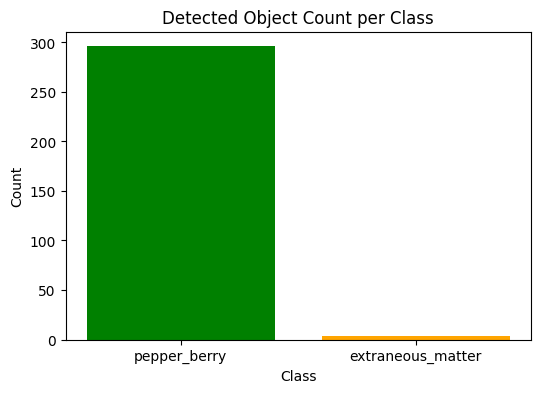

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color=["green", "orange", "red"])
plt.title("Detected Object Count per Class")
plt.ylabel("Count")
plt.xlabel("Class")
plt.show()

# Part C: Berry Cropping Pipeline (Dataset Generation)

## 1. Raw Dataset Upload and Extraction (Drive)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving raw_dataset.zip to raw_dataset.zip


In [ ]:
RAW_DATA_ROOT = "/content/drive/MyDrive/raw_dataset"

In [ ]:
!mkdir -p $RAW_DATA_ROOT
!unzip raw_dataset.zip -d $RAW_DATA_ROOT

Archive:  raw_dataset.zip
   creating: /content/drive/MyDrive/raw_dataset/raw_dataset/
   creating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_01/
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_01/close_01.jpg  
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_01/full_01.jpg  
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_01/half_01.jpg  
   creating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_02/
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_02/close_02.jpg  
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_02/full_02.jpg  
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_02/half_02.jpg  
   creating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_03/
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_03/close_03.jpg  
  inflating: /content/drive/MyDrive/raw_dataset/raw_dataset/sample_03/full_03.jpg  
  inflating: /content/dri

In [ ]:
!ls /content/drive/MyDrive/raw_dataset

raw_dataset


In [ ]:
!ls /content/drive/MyDrive/raw_dataset/raw_dataset

sample_01  sample_06  sample_11  sample_16  sample_21  sample_26
sample_02  sample_07  sample_12  sample_17  sample_22  sample_27
sample_03  sample_08  sample_13  sample_18  sample_23  sample_28
sample_04  sample_09  sample_14  sample_19  sample_24  sample_29
sample_05  sample_10  sample_15  sample_20  sample_25  sample_30


In [ ]:
!ls /content/drive/MyDrive/raw_dataset/raw_dataset/raw_dataset

ls: cannot access '/content/drive/MyDrive/raw_dataset/raw_dataset/raw_dataset': No such file or directory


## 2. Output Folder Setup for Cropped Berries

In [ ]:
BERRY_OUTPUT_DIR = "/content/drive/MyDrive/berry_crops_all"
!mkdir -p $BERRY_OUTPUT_DIR

## 3. Load YOLO Model for Cropping

In [ ]:
from ultralytics import YOLO
import cv2
import os

MODEL_PATH = "/content/drive/MyDrive/pepper_model_results/weights/yolov8s_best.pt"

model = YOLO(MODEL_PATH)
class_names = model.names

print(class_names)

{0: 'adulterant_seed', 1: 'extraneous_matter', 2: 'pepper_berry'}


## 4. Crop Function (Pepper Berry Only)

In [ ]:
berry_counter = 0

def crop_pepper_berries_from_image(image_path):
    global berry_counter

    img = cv2.imread(image_path)
    if img is None:
        return

    results = model(image_path, conf=0.25, iou=0.5)[0]

    if results.boxes is None:
        return

    for box, cls in zip(results.boxes.xyxy, results.boxes.cls):
        class_name = class_names[int(cls)]

        if class_name != "pepper_berry":
            continue

        x1, y1, x2, y2 = map(int, box.tolist())
        crop = img[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        save_path = os.path.join(
            BERRY_OUTPUT_DIR,
            f"berry_{berry_counter:06d}.jpg"
        )

        cv2.imwrite(save_path, crop)
        berry_counter += 1

## 5. Batch Cropping Over All Raw Images

In [ ]:
for root, dirs, files in os.walk(RAW_DATA_ROOT):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, file)
            crop_pepper_berries_from_image(img_path)

print("DONE")
print("Total pepper berries cropped:", berry_counter)
print("Saved to:", BERRY_OUTPUT_DIR)


image 1/1 /content/drive/MyDrive/raw_dataset3/raw_dataset/sample_01/full_01.jpg: 640x480 2 extraneous_matters, 220 pepper_berrys, 53.0ms
Speed: 4.1ms preprocess, 53.0ms inference, 235.1ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/MyDrive/raw_dataset3/raw_dataset/sample_01/half_01.jpg: 640x480 3 extraneous_matters, 227 pepper_berrys, 11.6ms
Speed: 7.0ms preprocess, 11.6ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/MyDrive/raw_dataset3/raw_dataset/sample_01/close_01.jpg: 640x480 19 extraneous_matters, 193 pepper_berrys, 11.3ms
Speed: 3.4ms preprocess, 11.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/MyDrive/raw_dataset3/raw_dataset/sample_02/full_02.jpg: 480x640 2 extraneous_matters, 212 pepper_berrys, 45.9ms
Speed: 3.8ms preprocess, 45.9ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/drive/MyDrive/raw_dataset3/raw_datas

# Part D: Cropping Test (Single Image Debug)

## 1. Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Upload ONE image

In [ ]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

Saving full_26.jpg to full_26.jpg
Uploaded image: full_26.jpg


## 3. Paths

In [ ]:
BERRY_OUTPUT_DIR = "/content/drive/MyDrive/berry_crops_test"
MODEL_PATH = "/content/drive/MyDrive/pepper_model_results/weights/yolov8s_best.pt"

import os
os.makedirs(BERRY_OUTPUT_DIR, exist_ok=True)

## 4. Load YOLO Model

In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO(MODEL_PATH)
class_names = model.names
print("Model classes:", class_names)

Model classes: {0: 'adulterant_seed', 1: 'extraneous_matter', 2: 'pepper_berry'}


## 5. Detect + Crop

In [ ]:
berry_counter = 0

img = cv2.imread(image_path)

results = model(image_path, conf=0.25, iou=0.5)[0]

if results.boxes is not None:
    for box, cls in zip(results.boxes.xyxy, results.boxes.cls):
        class_name = class_names[int(cls)]

        if class_name != "pepper_berry":
            continue

        x1, y1, x2, y2 = map(int, box.tolist())
        crop = img[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        save_path = os.path.join(
            BERRY_OUTPUT_DIR,
            f"berry_{berry_counter:03d}.jpg"
        )

        cv2.imwrite(save_path, crop)
        berry_counter += 1

print("DONE")
print("Total berries cropped:", berry_counter)
print("Saved to:", BERRY_OUTPUT_DIR)


image 1/1 /content/full_26.jpg: 640x480 219 pepper_berrys, 12.0ms
Speed: 3.3ms preprocess, 12.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
DONE
Total berries cropped: 219
Saved to: /content/drive/MyDrive/berry_crops_test6


# Part E: Classification Dataset Prep (Mold + Texture)

## 1. Upload and Extract Classification Dataset

In [ ]:
from google.colab import drive, files
import os, zipfile

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)

Saving berry_classification.zip to berry_classification.zip
Uploaded: berry_classification.zip


In [ ]:
DEST_ROOT = "/content/drive/MyDrive"
os.makedirs(DEST_ROOT, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DEST_ROOT)

print("Unzipped into:", DEST_ROOT)

Unzipped into: /content/drive/MyDrive


In [ ]:
!ls /content/drive/MyDrive/berry_classification

mold_dataset  texture_dataset


In [ ]:
!ls /content/drive/MyDrive/berry_classification/mold_dataset

healthy  mold


In [ ]:
!ls /content/drive/MyDrive/berry_classification/texture_dataset

abnormal_texture  good_texture


## 2. Automatic Train/Val Split for Both Datasets

In [ ]:
import random, shutil
from pathlib import Path

random.seed(42)

BASE = Path("/content/drive/MyDrive/berry_classification")

DATASETS = {
    "mold_dataset": ["healthy", "mold"],
    "texture_dataset": ["good_texture", "abnormal_texture"]
}

SPLIT_RATIO = 0.8

def clear_dir(p: Path):
    if p.exists():
        for f in p.glob("*"):
            if f.is_file():
                f.unlink()
            else:
                shutil.rmtree(f)

def split_one_dataset(ds_name: str, class_names: list[str]):
    ds_path = BASE / ds_name

    train_root = ds_path / "train"
    val_root   = ds_path / "val"

    # clean train/val if exists
    clear_dir(train_root)
    clear_dir(val_root)

    for cls in class_names:
        src = ds_path / cls
        assert src.exists(), f"Missing class folder: {src}"

        train_cls = train_root / cls
        val_cls   = val_root / cls
        train_cls.mkdir(parents=True, exist_ok=True)
        val_cls.mkdir(parents=True, exist_ok=True)

        imgs = []
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            imgs += list(src.glob(ext))

        assert len(imgs) > 0, f"No images found in {src}"

        random.shuffle(imgs)
        split_idx = int(len(imgs) * SPLIT_RATIO)

        train_imgs = imgs[:split_idx]
        val_imgs = imgs[split_idx:]

        for img in train_imgs:
            shutil.copy(img, train_cls / img.name)
        for img in val_imgs:
            shutil.copy(img, val_cls / img.name)

        print(f"[{ds_name}] {cls}: train={len(train_imgs)} val={len(val_imgs)}")

for ds_name, classes in DATASETS.items():
    split_one_dataset(ds_name, classes)

print("\n✅ Done splitting. Example folders:")
print("Mold train:", (BASE/'mold_dataset'/'train').exists())
print("Texture train:", (BASE/'texture_dataset'/'train').exists())

[mold_dataset] healthy: train=169 val=43
[mold_dataset] mold: train=179 val=45
[texture_dataset] good_texture: train=169 val=43
[texture_dataset] abnormal_texture: train=347 val=87

✅ Done splitting. Example folders:
Mold train: True
Texture train: True


In [ ]:
from pathlib import Path

def count_images(folder: str):
    p = Path(folder)
    return sum(1 for _ in p.rglob("*") if _.suffix.lower() in [".jpg",".jpeg",".png"])

print("Mold train images:", count_images("/content/drive/MyDrive/berry_classification/mold_dataset/train"))
print("Mold val images:", count_images("/content/drive/MyDrive/berry_classification/mold_dataset/val"))

print("Texture train images:", count_images("/content/drive/MyDrive/berry_classification/texture_dataset/train"))
print("Texture val images:", count_images("/content/drive/MyDrive/berry_classification/texture_dataset/val"))

Mold train images: 348
Mold val images: 88
Texture train images: 516
Texture val images: 130


# Part F: Classification Model 1 (Mold)

## Train MobileNetV3: Mold Classification

### 1. Settings and Paths

In [ ]:
!pip -q install torch torchvision

import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/berry_classification/mold_dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

SAVE_DIR = "/content/drive/MyDrive/pepper_model_results/classifiers"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "mobilenetv3_mold_best.pt")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


### 2. Data Augmentation and DataLoaders

In [ ]:
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

In [ ]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(VAL_DIR, transform=val_tfms)

print("Class mapping:", train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
assert num_classes == 2, "Mold dataset must have exactly 2 classes: healthy, mold"


Class mapping: {'healthy': 0, 'mold': 1}


### 3. Model Setup (MobileNetV3 Small)

In [ ]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 79.2MB/s]


### 4. Train + Evaluate

In [ ]:
best_val_acc = 0.0

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    acc = correct / total if total > 0 else 0
    return acc, np.concatenate(all_labels), np.concatenate(all_preds)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * y.size(0)

    train_loss = running_loss / len(train_ds)
    val_acc, y_true, y_pred = evaluate(model)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_ds.class_to_idx,
            "img_size": IMG_SIZE
        }, MODEL_SAVE_PATH)
        print("✅ Saved best model to:", MODEL_SAVE_PATH)

print("\nBest val accuracy:", best_val_acc)

Epoch 01/20 | train_loss=0.2149 | val_acc=0.8523
✅ Saved best model to: /content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_mold_best.pt
Epoch 02/20 | train_loss=0.1044 | val_acc=0.6136
Epoch 03/20 | train_loss=0.0683 | val_acc=0.8409
Epoch 04/20 | train_loss=0.0208 | val_acc=0.8523
Epoch 05/20 | train_loss=0.0115 | val_acc=0.8409
Epoch 06/20 | train_loss=0.0187 | val_acc=0.8977
✅ Saved best model to: /content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_mold_best.pt
Epoch 07/20 | train_loss=0.0336 | val_acc=1.0000
✅ Saved best model to: /content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_mold_best.pt
Epoch 08/20 | train_loss=0.0206 | val_acc=0.9545
Epoch 09/20 | train_loss=0.0159 | val_acc=0.9773
Epoch 10/20 | train_loss=0.0109 | val_acc=0.9886
Epoch 11/20 | train_loss=0.0230 | val_acc=1.0000
Epoch 12/20 | train_loss=0.0149 | val_acc=1.0000
Epoch 13/20 | train_loss=0.0042 | val_acc=0.9773
Epoch 14/20 | train_loss=0.0033 | val_acc=0.9886
Ep

### 5. Confusion matrix

In [ ]:
num = num_classes
cm = np.zeros((num, num), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)
print("Classes:", train_ds.classes)


Confusion Matrix (rows=true, cols=pred):
[[43  0]
 [ 1 44]]
Classes: ['healthy', 'mold']


# Part G: Classification Model 2 (Texture)

## Train MobileNetV3: Texture Classification

### 1. Settings and Paths

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/berry_classification/texture_dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

SAVE_DIR = "/content/drive/MyDrive/pepper_model_results/classifiers"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "mobilenetv3_texture_best.pt")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


### 2. Data Augmentation and DataLoaders

In [ ]:
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

In [ ]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(VAL_DIR, transform=val_tfms)

print("Class mapping:", train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
assert num_classes == 2, "Texture dataset must have exactly 2 classes: good_texture, abnormal_texture"


Class mapping: {'abnormal_texture': 0, 'good_texture': 1}


### 3. Model Setup (MobileNetV3 Small)

In [ ]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

### 4. Train + Evaluate

In [ ]:
best_val_acc = 0.0

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    acc = correct / total if total > 0 else 0
    return acc, np.concatenate(all_labels), np.concatenate(all_preds)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * y.size(0)

    train_loss = running_loss / len(train_ds)
    val_acc, y_true, y_pred = evaluate(model)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_ds.class_to_idx,
            "img_size": IMG_SIZE
        }, MODEL_SAVE_PATH)
        print("✅ Saved best model to:", MODEL_SAVE_PATH)

print("\nBest val accuracy:", best_val_acc)

Epoch 01/20 | train_loss=0.1957 | val_acc=0.8538
✅ Saved best model to: /content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_texture_best.pt
Epoch 02/20 | train_loss=0.0902 | val_acc=0.7769
Epoch 03/20 | train_loss=0.0531 | val_acc=0.9154
✅ Saved best model to: /content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_texture_best.pt
Epoch 04/20 | train_loss=0.0569 | val_acc=0.9923
✅ Saved best model to: /content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_texture_best.pt
Epoch 05/20 | train_loss=0.0609 | val_acc=0.9692
Epoch 06/20 | train_loss=0.0496 | val_acc=0.9923
Epoch 07/20 | train_loss=0.0136 | val_acc=0.9923
Epoch 08/20 | train_loss=0.0139 | val_acc=0.9692
Epoch 09/20 | train_loss=0.0406 | val_acc=0.9769
Epoch 10/20 | train_loss=0.0254 | val_acc=0.9846
Epoch 11/20 | train_loss=0.0773 | val_acc=0.9692
Epoch 12/20 | train_loss=0.0411 | val_acc=0.9538
Epoch 13/20 | train_loss=0.0318 | val_acc=0.9769
Epoch 14/20 | train_loss=0.0636 | val_acc=

### 5. Confusion matrix

In [ ]:
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)
print("Classes:", train_ds.classes)


Confusion Matrix (rows=true, cols=pred):
[[87  0]
 [15 28]]
Classes: ['abnormal_texture', 'good_texture']


# Part H: Single Image End-to-End Test (YOLO + Mold + Texture)

In [ ]:
!pip -q install ultralytics torch torchvision pillow

import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from ultralytics import YOLO
from torchvision import transforms, models
from PIL import Image
from collections import Counter
from google.colab import files

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 1. Paths

In [ ]:
YOLO_PATH = "/content/drive/MyDrive/pepper_model_results/weights/yolov8s_best.pt"

MOLD_CKPT = "/content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_mold_best.pt"

TEXT_CKPT = "/content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_texture_best.pt"

## 2. Load YOLO

In [ ]:
yolo = YOLO(YOLO_PATH)
yolo_names = yolo.names  # dict: id -> name
print("YOLO classes:", yolo_names)

YOLO classes: {0: 'adulterant_seed', 1: 'extraneous_matter', 2: 'pepper_berry'}


## 3. Load MobileNet checkpoints

In [ ]:
def load_mobilenet_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    class_to_idx = ckpt["class_to_idx"]
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    model = models.mobilenet_v3_small(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, len(class_to_idx))
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(DEVICE)
    model.eval()

    img_size = ckpt.get("img_size", 224)
    return model, idx_to_class, img_size

mold_model, mold_idx_to_class, IMG_SIZE = load_mobilenet_ckpt(MOLD_CKPT)
texture_model, texture_idx_to_class, _ = load_mobilenet_ckpt(TEXT_CKPT)

print("Mold classes:", mold_idx_to_class)
print("Texture classes:", texture_idx_to_class)

Mold classes: {0: 'healthy', 1: 'mold'}
Texture classes: {0: 'abnormal_texture', 1: 'good_texture'}


## 4. Preprocess

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predict_class(model, idx_to_class, crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(crop_rgb)
    x = preprocess(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        pred_idx = int(torch.argmax(logits, dim=1).item())
    return idx_to_class[pred_idx]

def pct(part, whole):
    return (part / whole * 100.0) if whole > 0 else 0.0

## 5. One image pipeline

In [ ]:
def run_single_image_pipeline(image_path, conf=0.25, iou=0.5):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Cannot read image: " + image_path)

    res = yolo(image_path, conf=conf, iou=iou)[0]

    # YOLO object counts + berry crops
    obj_counts = Counter()
    berry_crops = []

    if res.boxes is not None and len(res.boxes) > 0:
        for box, cls in zip(res.boxes.xyxy, res.boxes.cls):
            cls_name = yolo_names[int(cls)]
            obj_counts[cls_name] += 1

            if cls_name == "pepper_berry":
                x1, y1, x2, y2 = map(int, box.tolist())
                crop = img[y1:y2, x1:x2]
                if crop.size != 0:
                    berry_crops.append(crop)

    total_objects = sum(obj_counts.values())
    pepper_count = obj_counts.get("pepper_berry", 0)
    adulterant_count = obj_counts.get("adulterant_seed", 0)
    extraneous_count = obj_counts.get("extraneous_matter", 0)

    # Classifier counts (berries only)
    mold_count = 0
    abnormal_texture_count = 0
    good_texture_count = 0

    for crop in berry_crops:
        mold_pred = predict_class(mold_model, mold_idx_to_class, crop)

        # Rule: if mold, do NOT check texture
        if mold_pred == "mold":
            mold_count += 1
            continue

        tex_pred = predict_class(texture_model, texture_idx_to_class, crop)
        if tex_pred == "abnormal_texture":
            abnormal_texture_count += 1
        else:
            good_texture_count += 1

    healthy_visual_count = pepper_count - mold_count - abnormal_texture_count
    if healthy_visual_count < 0:
        healthy_visual_count = 0

    # ----------------------------
    # Percentages
    # ----------------------------

    # Option A: proportion from total YOLO objects
    adulterant_pct_total_objects = pct(adulterant_count, total_objects)
    extraneous_pct_total_objects = pct(extraneous_count, total_objects)

    # Option B (extra, foreign-only ratio)
    foreign_total = adulterant_count + extraneous_count
    adulterant_pct_foreign_only = pct(adulterant_count, foreign_total)
    extraneous_pct_foreign_only = pct(extraneous_count, foreign_total)

    # Berry-level quality percentages
    mold_pct_pepper = pct(mold_count, pepper_count)
    abnormal_texture_pct_pepper = pct(abnormal_texture_count, pepper_count)
    healthy_visual_pct_pepper = pct(healthy_visual_count, pepper_count)

    # ----------------------------
    # Print summary
    # ----------------------------
    print("\n================ YOLO COUNTS ================")
    print("Total objects:", total_objects)
    print("pepper_berry:", pepper_count)
    print("adulterant_seed:", adulterant_count)
    print("extraneous_matter:", extraneous_count)

    print("\n=========== CLASSIFIER COUNTS (BERRIES) ===========")
    print("mold:", mold_count)
    print("abnormal_texture:", abnormal_texture_count)
    print("good_texture:", good_texture_count)
    print("healthy_visual:", healthy_visual_count)

    print("\n================ PERCENTAGES ================")
    print(f"  adulterant_seed%: {adulterant_pct_total_objects:.2f}%")
    print(f"  extraneous_matter%: {extraneous_pct_total_objects:.2f}%")
    print(f"  mold%: {mold_pct_pepper:.2f}%")
    print(f"  abnormal_texture%: {abnormal_texture_pct_pepper:.2f}%")
    print(f"  healthy_visual%: {healthy_visual_pct_pepper:.2f}%")

## 6. Upload 1 image and run

In [ ]:
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
run_single_image_pipeline(img_name)

Saving full_28.jpg to full_28.jpg

image 1/1 /content/full_28.jpg: 640x480 219 pepper_berrys, 11.4ms
Speed: 3.3ms preprocess, 11.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)

================ YOLO COUNTS ================
Total objects: 219
pepper_berry: 219
adulterant_seed: 0
extraneous_matter: 0

=========== CLASSIFIER COUNTS (BERRIES) ===========
mold: 51
abnormal_texture: 167
good_texture: 1
healthy_visual: 1

================ PERCENTAGES ================
  adulterant_seed%: 0.00%
  extraneous_matter%: 0.00%
  mold%: 23.29%
  abnormal_texture%: 76.26%
  healthy_visual%: 0.46%


# Part I: 3 images, average of percentages

In [ ]:
!pip -q install ultralytics torch torchvision pillow

import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from ultralytics import YOLO
from torchvision import transforms, models
from PIL import Image
from collections import Counter
from google.colab import files

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

YOLO_PATH = "/content/drive/MyDrive/pepper_model_results/weights/yolov8s_best.pt"
MOLD_CKPT = "/content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_mold_best.pt"
TEXT_CKPT = "/content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_texture_best.pt"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


## Load YOLO

In [ ]:
yolo = YOLO(YOLO_PATH)
yolo_names = yolo.names
print("YOLO classes:", yolo_names)

YOLO classes: {0: 'adulterant_seed', 1: 'extraneous_matter', 2: 'pepper_berry'}


## Load MobileNet checkpoints

In [ ]:
def load_mobilenet_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    class_to_idx = ckpt["class_to_idx"]
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    model = models.mobilenet_v3_small(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, len(class_to_idx))
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(DEVICE)
    model.eval()

    img_size = ckpt.get("img_size", 224)
    return model, idx_to_class, img_size

mold_model, mold_idx_to_class, IMG_SIZE = load_mobilenet_ckpt(MOLD_CKPT)
texture_model, texture_idx_to_class, _ = load_mobilenet_ckpt(TEXT_CKPT)

print("Mold classes:", mold_idx_to_class)
print("Texture classes:", texture_idx_to_class)

Mold classes: {0: 'healthy', 1: 'mold'}
Texture classes: {0: 'abnormal_texture', 1: 'good_texture'}


## Preprocess + helpers

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predict_class(model, idx_to_class, crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(crop_rgb)
    x = preprocess(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        pred_idx = int(torch.argmax(logits, dim=1).item())
    return idx_to_class[pred_idx]

def pct(part, whole):
    return (part / whole * 100.0) if whole > 0 else 0.0

## Run pipeline on ONE image. Returns: counts + percentages

In [ ]:
def run_single_image_pipeline(image_path, conf=0.25, iou=0.5, print_output=True):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Cannot read image: " + image_path)

    res = yolo(image_path, conf=conf, iou=iou)[0]

    obj_counts = Counter()
    berry_crops = []

    if res.boxes is not None and len(res.boxes) > 0:
        for box, cls in zip(res.boxes.xyxy, res.boxes.cls):
            cls_name = yolo_names[int(cls)]
            obj_counts[cls_name] += 1

            if cls_name == "pepper_berry":
                x1, y1, x2, y2 = map(int, box.tolist())
                crop = img[y1:y2, x1:x2]
                if crop.size != 0:
                    berry_crops.append(crop)

    total_objects = sum(obj_counts.values())
    pepper_count = obj_counts.get("pepper_berry", 0)
    adulterant_count = obj_counts.get("adulterant_seed", 0)
    extraneous_count = obj_counts.get("extraneous_matter", 0)

    mold_count = 0
    abnormal_texture_count = 0
    good_texture_count = 0

    for crop in berry_crops:
        mold_pred = predict_class(mold_model, mold_idx_to_class, crop)
        if mold_pred == "mold":
            mold_count += 1
            continue

        tex_pred = predict_class(texture_model, texture_idx_to_class, crop)
        if tex_pred == "abnormal_texture":
            abnormal_texture_count += 1
        else:
            good_texture_count += 1

    healthy_visual_count = pepper_count - mold_count - abnormal_texture_count
    if healthy_visual_count < 0:
        healthy_visual_count = 0

    # Percentages for this image (your 5 factors)
    adulterant_pct_total_objects = pct(adulterant_count, total_objects)
    extraneous_pct_total_objects = pct(extraneous_count, total_objects)
    mold_pct_pepper = pct(mold_count, pepper_count)
    abnormal_texture_pct_pepper = pct(abnormal_texture_count, pepper_count)
    healthy_visual_pct_pepper = pct(healthy_visual_count, pepper_count)

    # store
    result = {
        "image": os.path.basename(image_path),

        "counts": {
            "total_objects": total_objects,
            "pepper_berry": pepper_count,
            "adulterant_seed": adulterant_count,
            "extraneous_matter": extraneous_count,
            "mold": mold_count,
            "abnormal_texture": abnormal_texture_count,
            "good_texture": good_texture_count,
            "healthy_visual": healthy_visual_count,
        },

        "pct": {
            "adulterant_seed_pct": adulterant_pct_total_objects,
            "extraneous_matter_pct": extraneous_pct_total_objects,
            "mold_pct": mold_pct_pepper,
            "abnormal_texture_pct": abnormal_texture_pct_pepper,
            "healthy_visual_pct": healthy_visual_pct_pepper,
        }
    }

    if print_output:
        print(f"\n================ IMAGE: {result['image']} ================")
        c = result["counts"]
        p = result["pct"]

        print("YOLO counts:")
        print("  total_objects:", c["total_objects"])
        print("  pepper_berry:", c["pepper_berry"])
        print("  adulterant_seed:", c["adulterant_seed"])
        print("  extraneous_matter:", c["extraneous_matter"])

        print("Classifier counts (berries):")
        print("  mold:", c["mold"])
        print("  abnormal_texture:", c["abnormal_texture"])
        print("  good_texture:", c["good_texture"])
        print("  healthy_visual:", c["healthy_visual"])

        print("Percentages (this image):")
        print(f"  adulterant_seed%: {p['adulterant_seed_pct']:.2f}%")
        print(f"  extraneous_matter%: {p['extraneous_matter_pct']:.2f}%")
        print(f"  mold%: {p['mold_pct']:.2f}%")
        print(f"  abnormal_texture%: {p['abnormal_texture_pct']:.2f}%")
        print(f"  healthy_visual%: {p['healthy_visual_pct']:.2f}%")

    return result

## Run for 3 images and AVERAGE the percentages

In [ ]:
def run_three_images_average_percentages(image_paths):
    results = [run_single_image_pipeline(p, print_output=True) for p in image_paths]

    # simple average of percentages (your method)
    keys = ["adulterant_seed_pct", "extraneous_matter_pct", "mold_pct", "abnormal_texture_pct", "healthy_visual_pct"]

    avg = {}
    for k in keys:
        avg[k] = sum(r["pct"][k] for r in results) / len(results)

    print("\n================ FINAL (Average of 3 image percentages) ================")
    print(f"adulterant_seed% (avg): {avg['adulterant_seed_pct']:.2f}%")
    print(f"extraneous_matter% (avg): {avg['extraneous_matter_pct']:.2f}%")
    print(f"mold% (avg): {avg['mold_pct']:.2f}%")
    print(f"abnormal_texture% (avg): {avg['abnormal_texture_pct']:.2f}%")
    print(f"healthy_visual% (avg): {avg['healthy_visual_pct']:.2f}%")


## Upload 3 images at once and run

In [ ]:
uploaded = files.upload()
paths = list(uploaded.keys())

# Sort so it prints in nice order if filenames contain full/half/close
paths_sorted = sorted(paths)
print("Uploaded files:", paths_sorted)

if len(paths_sorted) != 3:
    print("⚠️ Please upload exactly 3 images: full_XX.jpg, half_XX.jpg, close_XX.jpg")
else:
    run_three_images_average_percentages(paths_sorted)

Saving close_01.jpg to close_01.jpg
Saving full_01.jpg to full_01.jpg
Saving half_01.jpg to half_01.jpg
Uploaded files: ['close_01.jpg', 'full_01.jpg', 'half_01.jpg']

image 1/1 /content/close_01.jpg: 640x480 29 extraneous_matters, 183 pepper_berrys, 45.0ms
Speed: 9.8ms preprocess, 45.0ms inference, 41.7ms postprocess per image at shape (1, 3, 640, 480)

================ IMAGE: close_01.jpg ================
YOLO counts:
  total_objects: 212
  pepper_berry: 183
  adulterant_seed: 0
  extraneous_matter: 29
Classifier counts (berries):
  mold: 2
  abnormal_texture: 54
  good_texture: 127
  healthy_visual: 127
Percentages (this image):
  adulterant_seed%: 0.00%
  extraneous_matter%: 13.68%
  mold%: 1.09%
  abnormal_texture%: 29.51%
  healthy_visual%: 69.40%

image 1/1 /content/full_01.jpg: 640x480 3 extraneous_matters, 220 pepper_berrys, 11.2ms
Speed: 2.9ms preprocess, 11.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)

================ IMAGE: full_01.jpg =============

# Part J: Upload 9 images, compute sample averages, then final batch average

In [ ]:
!pip -q install ultralytics torch torchvision pillow

import os
import cv2
import torch
import torch.nn as nn
from ultralytics import YOLO
from torchvision import transforms, models
from PIL import Image
from collections import Counter
from google.colab import files

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

YOLO_PATH = "/content/drive/MyDrive/pepper_model_results/weights/yolov8s_best.pt"
MOLD_CKPT = "/content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_mold_best.pt"
TEXT_CKPT = "/content/drive/MyDrive/pepper_model_results/classifiers/mobilenetv3_texture_best.pt"

Device: cuda


## Load models

In [ ]:
yolo = YOLO(YOLO_PATH)
yolo_names = yolo.names
print("YOLO classes:", yolo_names)

def load_mobilenet_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    class_to_idx = ckpt["class_to_idx"]
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    model = models.mobilenet_v3_small(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, len(class_to_idx))
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(DEVICE)
    model.eval()

    img_size = ckpt.get("img_size", 224)
    return model, idx_to_class, img_size

mold_model, mold_idx_to_class, IMG_SIZE = load_mobilenet_ckpt(MOLD_CKPT)
texture_model, texture_idx_to_class, _ = load_mobilenet_ckpt(TEXT_CKPT)

print("Mold classes:", mold_idx_to_class)
print("Texture classes:", texture_idx_to_class)

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predict_class(model, idx_to_class, crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(crop_rgb)
    x = preprocess(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        pred_idx = int(torch.argmax(logits, dim=1).item())
    return idx_to_class[pred_idx]

def pct(part, whole):
    return (part / whole * 100.0) if whole > 0 else 0.0

YOLO classes: {0: 'adulterant_seed', 1: 'extraneous_matter', 2: 'pepper_berry'}
Mold classes: {0: 'healthy', 1: 'mold'}
Texture classes: {0: 'abnormal_texture', 1: 'good_texture'}


## One image pipeline (returns pct dict)

In [ ]:
def run_single_image_pipeline(image_path, conf=0.25, iou=0.5, print_output=True):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Cannot read image: " + image_path)

    res = yolo(image_path, conf=conf, iou=iou)[0]

    obj_counts = Counter()
    berry_crops = []

    if res.boxes is not None and len(res.boxes) > 0:
        for box, cls in zip(res.boxes.xyxy, res.boxes.cls):
            cls_name = yolo_names[int(cls)]
            obj_counts[cls_name] += 1

            if cls_name == "pepper_berry":
                x1, y1, x2, y2 = map(int, box.tolist())
                crop = img[y1:y2, x1:x2]
                if crop.size != 0:
                    berry_crops.append(crop)

    total_objects = sum(obj_counts.values())
    pepper_count = obj_counts.get("pepper_berry", 0)
    adulterant_count = obj_counts.get("adulterant_seed", 0)
    extraneous_count = obj_counts.get("extraneous_matter", 0)

    mold_count = 0
    abnormal_texture_count = 0

    for crop in berry_crops:
        mold_pred = predict_class(mold_model, mold_idx_to_class, crop)
        if mold_pred == "mold":
            mold_count += 1
            continue

        tex_pred = predict_class(texture_model, texture_idx_to_class, crop)
        if tex_pred == "abnormal_texture":
            abnormal_texture_count += 1

    healthy_visual_count = pepper_count - mold_count - abnormal_texture_count
    if healthy_visual_count < 0:
        healthy_visual_count = 0

    pcts = {
        "adulterant_seed_pct": pct(adulterant_count, total_objects),
        "extraneous_matter_pct": pct(extraneous_count, total_objects),
        "mold_pct": pct(mold_count, pepper_count),
        "abnormal_texture_pct": pct(abnormal_texture_count, pepper_count),
        "healthy_visual_pct": pct(healthy_visual_count, pepper_count),
    }

    if print_output:
        print(f"\nIMAGE: {os.path.basename(image_path)}")
        print(f"  adulterant_seed%: {pcts['adulterant_seed_pct']:.2f}%")
        print(f"  extraneous_matter%: {pcts['extraneous_matter_pct']:.2f}%")
        print(f"  mold%: {pcts['mold_pct']:.2f}%")
        print(f"  abnormal_texture%: {pcts['abnormal_texture_pct']:.2f}%")
        print(f"  healthy_visual%: {pcts['healthy_visual_pct']:.2f}%")

    return pcts

## Average percentages for a list of images

In [ ]:
PCT_KEYS = ["adulterant_seed_pct","extraneous_matter_pct","mold_pct","abnormal_texture_pct","healthy_visual_pct"]

def avg_pct_dict(list_of_pct_dicts):
    avg = {}
    for k in PCT_KEYS:
        avg[k] = sum(d[k] for d in list_of_pct_dicts) / len(list_of_pct_dicts)
    return avg

def print_pct_block(title, pct_dict):
    print(f"\n===== {title} =====")
    print(f"adulterant_seed%: {pct_dict['adulterant_seed_pct']:.2f}%")
    print(f"extraneous_matter%: {pct_dict['extraneous_matter_pct']:.2f}%")
    print(f"mold%: {pct_dict['mold_pct']:.2f}%")
    print(f"abnormal_texture%: {pct_dict['abnormal_texture_pct']:.2f}%")
    print(f"healthy_visual%: {pct_dict['healthy_visual_pct']:.2f}%")

## 9-image batch: 3 samples, each sample has 3 images

In [ ]:
def run_9_images_three_samples(sample_to_images):
    sample_avgs = {}

    for sample_name, img_paths in sample_to_images.items():
        print(f"\n\n================ SAMPLE: {sample_name.upper()} ================")
        per_image = [run_single_image_pipeline(p, print_output=True) for p in img_paths]
        sample_avg = avg_pct_dict(per_image)
        sample_avgs[sample_name] = sample_avg
        print_pct_block(f"{sample_name.upper()} SAMPLE AVG (3 images)", sample_avg)

    # final: average of 3 sample averages
    final_avg = avg_pct_dict(list(sample_avgs.values()))
    print_pct_block("FINAL BATCH AVG (avg of 3 sample avgs)", final_avg)

## Upload 9 images and map them to bottom/middle/top

In [ ]:
uploaded = files.upload()
uploaded_files = list(uploaded.keys())
print("Uploaded:", sorted(uploaded_files))

if len(uploaded_files) != 9:
    print("⚠️ Please upload exactly 9 images (3 samples x 3 images).")
else:
    # Recommended filename format:
    # bottom_full.jpg, bottom_half.jpg, bottom_close.jpg
    # middle_full.jpg, middle_half.jpg, middle_close.jpg
    # top_full.jpg, top_half.jpg, top_close.jpg

    def find_file(sample, view):
        # view in {"full","half","close"}
        for f in uploaded_files:
            name = f.lower()
            if sample in name and view in name:
                return f
        return None

    mapping = {}
    for s in ["bottom","middle","top"]:
        mapping[s] = [find_file(s, "full"), find_file(s, "half"), find_file(s, "close")]

    # Check mapping
    missing = []
    for s, lst in mapping.items():
        if any(x is None for x in lst):
            missing.append((s, lst))

    if missing:
        print("⚠️ Filenames not matched. Please use names like bottom_full.jpg etc.")
        print("Missing mapping:", missing)
    else:
        run_9_images_three_samples(mapping)

Saving bottom_close.jpg to bottom_close.jpg
Saving bottom_full.jpg to bottom_full.jpg
Saving bottom_half.jpg to bottom_half.jpg
Saving middle_close.jpg to middle_close.jpg
Saving middle_full.jpg to middle_full.jpg
Saving middle_half.jpg to middle_half.jpg
Saving top_close.jpg to top_close.jpg
Saving top_full.jpg to top_full.jpg
Saving top_half.jpg to top_half.jpg
Uploaded: ['bottom_close.jpg', 'bottom_full.jpg', 'bottom_half.jpg', 'middle_close.jpg', 'middle_full.jpg', 'middle_half.jpg', 'top_close.jpg', 'top_full.jpg', 'top_half.jpg']


================ SAMPLE: BOTTOM ================

image 1/1 /content/bottom_full.jpg: 480x640 6 extraneous_matters, 186 pepper_berrys, 45.4ms
Speed: 3.6ms preprocess, 45.4ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

IMAGE: bottom_full.jpg
  adulterant_seed%: 0.00%
  extraneous_matter%: 3.12%
  mold%: 0.00%
  abnormal_texture%: 12.37%
  healthy_visual%: 87.63%

image 1/1 /content/bottom_half.jpg: 640x480 7 extraneous_matters, 192